# Multi BKT Example Using Simulated Grouped Data

This walkthrough mirrors the simple example (`02_simple_example.ipynb`) but uses grouped data and `MultiBKT`.

In this notebook, we will:

1. Simulate grouped BKT data with group- and KC-specific parameters.
2. Instantiate and fit a `MultiBKT` model.
3. Generate Numba-accelerated point-estimate predictions (`predict` and `predict_smoothed`).

This example stops after fitting and Numba-based predictions.


## Simulate Grouped BKT Data

We simulate students from multiple groups. Each group can have different BKT parameters, and in this example, parameters also vary across KCs.


In [1]:
from stanbkt.utils import sim_grouped_BKT

In [2]:
N_GROUPS = 3
N_KCS = 2

# rows=groups, cols=KCs
bkt_params = {
    "prior": [[0.20, 0.10], [0.35, 0.25], [0.50, 0.40]],
    "learn": [[0.03, 0.06], [0.05, 0.08], [0.08, 0.10]],
    "forget": [[0.01, 0.01], [0.02, 0.02], [0.02, 0.03]],
    "guess": [[0.25, 0.20], [0.20, 0.15], [0.15, 0.10]],
    "slip": [[0.10, 0.08], [0.08, 0.07], [0.06, 0.05]],
}

In [3]:
data_df = sim_grouped_BKT(
    n_students=60,
    n_problems=80,
    n_kcs=N_KCS,
    n_groups=N_GROUPS,
    frac=0.85,
    rng_seed=12345,
    **bkt_params,
)

In [4]:
data_df.head(10)

,student_id,problem_id,correct,timestamp,kc_id,group_id
0,stu_0,prob_0,0,2024-01-01 00:00:00,kc_1,group_0
1,stu_0,prob_1,1,2024-01-01 00:01:00,kc_0,group_0
2,stu_0,prob_2,0,2024-01-01 00:02:00,kc_1,group_0
3,stu_0,prob_3,1,2024-01-01 00:03:00,kc_0,group_0
4,stu_0,prob_4,1,2024-01-01 00:04:00,kc_0,group_0
5,stu_0,prob_6,0,2024-01-01 00:06:00,kc_1,group_0
6,stu_0,prob_7,1,2024-01-01 00:07:00,kc_1,group_0
7,stu_0,prob_8,1,2024-01-01 00:08:00,kc_1,group_0
8,stu_0,prob_9,1,2024-01-01 00:09:00,kc_0,group_0
9,stu_0,prob_10,0,2024-01-01 00:10:00,kc_1,group_0


In [5]:
data_df[["group_id", "kc_id"]].value_counts().sort_index()

group_id  kc_id
group_0   kc_0     658
          kc_1     700
group_1   kc_0     663
          kc_1     705
group_2   kc_0     656
          kc_1     698
Name: count, dtype: int64

`MultiBKT` expects long-format data including the standard columns (`student_id`, `problem_id`, `correct`, `timestamp`, `kc_id`) plus `group_id`.


In [6]:
required_cols = [
    "student_id",
    "problem_id",
    "correct",
    "timestamp",
    "kc_id",
    "group_id",
]
data_df[required_cols].head(5)

,student_id,problem_id,correct,timestamp,kc_id,group_id
0,stu_0,prob_0,0,2024-01-01 00:00:00,kc_1,group_0
1,stu_0,prob_1,1,2024-01-01 00:01:00,kc_0,group_0
2,stu_0,prob_2,0,2024-01-01 00:02:00,kc_1,group_0
3,stu_0,prob_3,1,2024-01-01 00:03:00,kc_0,group_0
4,stu_0,prob_4,1,2024-01-01 00:04:00,kc_0,group_0


## Instantiate and fit `MultiBKT`

As in the simple example, Stan code is compiled lazily on the first `fit(...)` call and cached for reuse.


In [7]:
from stanbkt.models import MultiBKT
from stanbkt.fits import FitMethod, MCMCFitOptions
from stanbkt.models import MultiPriors
from stanbkt.utils import VerbosityLevel

In [8]:
model = MultiBKT(
    fit_method=FitMethod.MCMC,
    verbose=VerbosityLevel.WARN,
)

fit_opts = MCMCFitOptions(
    seed=1234,
    iter_warmup=500,
    iter_sampling=500,
)

priors = MultiPriors(use_defaults=True)  # using default priors for all groups and KCs

Unlike the previous example (`02_simple_example.ipynb`), we will pass the entire DataFrame containing both KCs.


In [9]:
model.fit(data_df, stan_fit_options=fit_opts, priors=priors)

17:00:36 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

...

chain 2:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

17:00:55 - cmdstanpy - INFO - CmdStan done processing.


MultiBKT(fit_method=<FitMethod.MCMC: 'mcmc'>, verbose=<VerbosityLevel.WARN: 1>, is_fitted=True)

Generate a summary of the parameters' posterior distributions.


In [10]:
summary = model.summary()
summary

Mean      MCSE    StdDev       MAD  \
kc_id parameter                                                          
kc_1  lp__                   -921.694000  0.118435  3.010790  2.884400   
      logit_pi_know_group[1]   -3.428550  0.085990  2.119080  1.248890   
      logit_pi_know_group[2]   -0.953987  0.015008  0.626301  0.585673   
      logit_pi_know_group[3]    0.063329  0.009998  0.541030  0.517822   
      logit_learn_group[1]     -2.610510  0.004827  0.250038  0.254466   
...                                  ...       ...       ...       ...   
kc_0  guess[2]                  0.206578  0.000706  0.035417  0.036829   
      guess[3]                  0.148244  0.000900  0.039277  0.039619   
      slip[1]                   0.096202  0.000450  0.019514  0.018577   
      slip[2]                   0.048679  0.000269  0.012363  0.012165   
      slip[3]                   0.039134  0.000215  0.010497  0.010506   

                                    2.5%         50%       97.5%  ESS_bulk  \
kc_id parameter                                                              
kc_1  lp__                   -928.645000 -921.360000 -916.903000   660.542   
      logit_pi_know_group[1]   -9.653540   -2.811810   -1.208540  1028.270   
      logit_pi_know_group[2]   -2.271920   -0.910853    0.165178  2127.500   
      logit_pi_know_group[3]   -1.026090    0.077880    1.113430  2983.860   
      logit_learn_group[1]     -3.126990   -2.605160   -2.150770  2962.300   
...                                  ...         ...         ...       ...   
kc_0  guess[2]                  0.141762    0.205580    0.279148  2559.340   
      guess[3]                  0.079686    0.146121    0.233238  1955.870   
      slip[1]                   0.060655    0.095115    0.138666  1905.790   
      slip[2]                   0.027220    0.047605    0.075275  2159.430   
      slip[3]                   0.020468    0.038814    0.061320  2326.940   

                              ESS_tail     R_hat  
kc_id parameter                                   
kc_1  lp__                     843.480  1.002110  
      logit_pi_know_group[1]   871.355  1.008320  
      logit_pi_know_group[2]  1143.810  1.001320  
      logit_pi_know_group[3]  1291.860  0.999119  
      logit_learn_group[1]    1118.880  1.001850  
...                                ...       ...  
kc_0  guess[2]                1405.850  1.003210  
      guess[3]                1367.580  1.001490  
      slip[1]                 1533.050  1.002140  
      slip[2]                 1354.460  1.000900  
      slip[3]                 1208.900  1.001970  

[62 rows x 10 columns]

In [11]:
summary.loc["kc_0"]  # summary for kc_0

,Mean,MCSE,StdDev,MAD,2.5%,50%,97.5%,ESS_bulk,ESS_tail,R_hat
parameter,,,,,,,,,,
lp__,-837.621000,0.108199,2.998410,2.808790,-844.811000,-837.255000,-832.962000,800.308,1268.890,1.002780
logit_pi_know_group[1],-1.186370,0.016435,0.665201,0.602940,-2.679060,-1.115120,-0.057710,1958.970,1067.480,1.003470
logit_pi_know_group[2],0.612810,0.012302,0.562335,0.570284,-0.454810,0.600089,1.745280,2128.260,1473.040,0.999152
logit_pi_know_group[3],1.053900,0.014190,0.630915,0.560652,-0.109400,1.015180,2.427780,2303.210,1122.930,1.001530
logit_learn_group[1],-3.303280,0.008623,0.383281,0.364401,-4.125830,-3.265930,-2.636570,2149.770,1240.310,0.999253
logit_learn_group[2],-2.791580,0.008285,0.382229,0.385587,-3.613330,-2.774590,-2.097270,2205.470,1401.090,1.004720
logit_learn_group[3],-2.138990,0.007243,0.320278,0.303473,-2.830860,-2.117300,-1.555850,2049.870,1156.790,1.002120
logit_forget_group[1],-5.545130,0.058078,1.518500,1.055960,-10.029100,-5.232840,-3.670290,1321.660,575.351,1.004160
logit_forget_group[2],-3.417570,0.006945,0.331542,0.317573,-4.118930,-3.394710,-2.817380,2410.420,1507.380,0.999805


## Numba-based point-estimate predictions

`predict(...)` and `predict_smoothed(...)` use Numba-compiled routines internally for fast inference with Bayesian point estimates for the parameters.


In [12]:
from stanbkt.utils.data_utils import ColumnNames

col_mapping = {
    ColumnNames.STUDENT_ID: "student_id",
    ColumnNames.PROBLEM_ID: "problem_id",
    ColumnNames.CORRECTNESS: "correct",
    ColumnNames.ORDER: "timestamp",
    ColumnNames.KC_ID: "kc_id",
    ColumnNames.GROUP: "group_id",
}

In [13]:
predictions = model.predict(
    data_df,
    column_mapping=col_mapping,
    point_estimate="mean",
    parallel=True,
    fast_math=True,
)

predictions.head(20)

,kc_id,student_id,problem_id,pKnow,pCorrectness,correct
0,kc_1,stu_0,prob_0,0.072479,0.216648,0
1,kc_1,stu_0,prob_2,0.079254,0.221594,0
2,kc_1,stu_0,prob_6,0.080166,0.222260,0
3,kc_1,stu_0,prob_7,0.080290,0.222350,1
4,kc_1,stu_0,prob_8,0.368654,0.432900,1
5,kc_1,stu_0,prob_10,0.774099,0.728935,0
6,kc_1,stu_0,prob_12,0.350429,0.419592,0
7,kc_1,stu_0,prob_17,0.129425,0.258227,0
8,kc_1,stu_0,prob_19,0.087297,0.227467,0
9,kc_1,stu_0,prob_20,0.081264,0.223061,0


In [14]:
smoothed_predictions = model.predict_smoothed(
    data_df,
    column_mapping=col_mapping,
    point_estimate="mean",
    parallel=True,
    fast_math=True,
)

smoothed_predictions.head(20)

,kc_id,student_id,problem_id,pKnow,pCorrectness,correct
0,kc_1,stu_0,prob_0,0.000107,0.163805,0
1,kc_1,stu_0,prob_2,0.000427,0.164039,0
2,kc_1,stu_0,prob_6,0.002743,0.165730,0
3,kc_1,stu_0,prob_7,0.019798,0.178182,1
4,kc_1,stu_0,prob_8,0.019798,0.178183,1
5,kc_1,stu_0,prob_10,0.002748,0.165733,0
6,kc_1,stu_0,prob_12,0.000434,0.164043,0
7,kc_1,stu_0,prob_17,0.000120,0.163814,0
8,kc_1,stu_0,prob_19,0.000077,0.163783,0
9,kc_1,stu_0,prob_20,0.000071,0.163779,0


## Predictions and Visualizations

As `MultiBKT` estimates a separate set of parameters for each group, posterior correctness can be visualized in two ways.

By default, `plot_posterior_correctness(...)` aggregates across groups and produces a single panel for the selected KC. If you want to inspect how posterior correctness differs by group, pass `grouped=True`. In that mode, the function creates one subplot per group.


In [15]:
pred_post_draws = model.predict_posterior_draws(data_df, column_mapping=col_mapping)

17:00:56 - cmdstanpy - INFO - Chain [1] start processing
17:00:56 - cmdstanpy - INFO - Chain [2] start processing
17:00:56 - cmdstanpy - INFO - Chain [3] start processing
17:00:56 - cmdstanpy - INFO - Chain [4] start processing


17:00:57 - cmdstanpy - INFO - Chain [1] done processing
17:00:57 - cmdstanpy - INFO - Chain [2] done processing
17:00:57 - cmdstanpy - INFO - Chain [4] done processing
17:00:57 - cmdstanpy - INFO - Chain [3] done processing
17:00:57 - cmdstanpy - INFO - Chain [1] start processing
17:00:57 - cmdstanpy - INFO - Chain [2] start processing
17:00:57 - cmdstanpy - INFO - Chain [3] start processing
17:00:57 - cmdstanpy - INFO - Chain [4] start processing
17:00:57 - cmdstanpy - INFO - Chain [1] done processing
17:00:57 - cmdstanpy - INFO - Chain [4] done processing
17:00:57 - cmdstanpy - INFO - Chain [3] done processing
17:00:57 - cmdstanpy - INFO - Chain [2] done processing
17:00:58 - cmdstanpy - WARNING - Sample doesn't contain draws from warmup iterations, rerun sampler with "save_warmup=True".
17:00:59 - cmdstanpy - WARNING - Sample doesn't contain draws from warmup iterations, rerun sampler with "save_warmup=True".


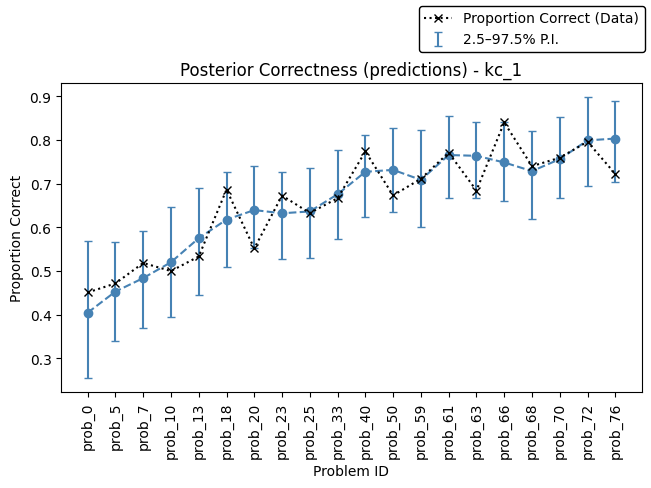

In [ ]:
from stanbkt.plot import plot_posterior_correctness

# correctness predictions (with predictive intervals)
axes = plot_posterior_correctness(
    posterior_pred_kc=pred_post_draws["kc_1"],
    data=data_df,
    column_mapping=col_mapping,
    kc="kc_1",
    type="preds",
    trajectory=True,
    frac=0.5,
)

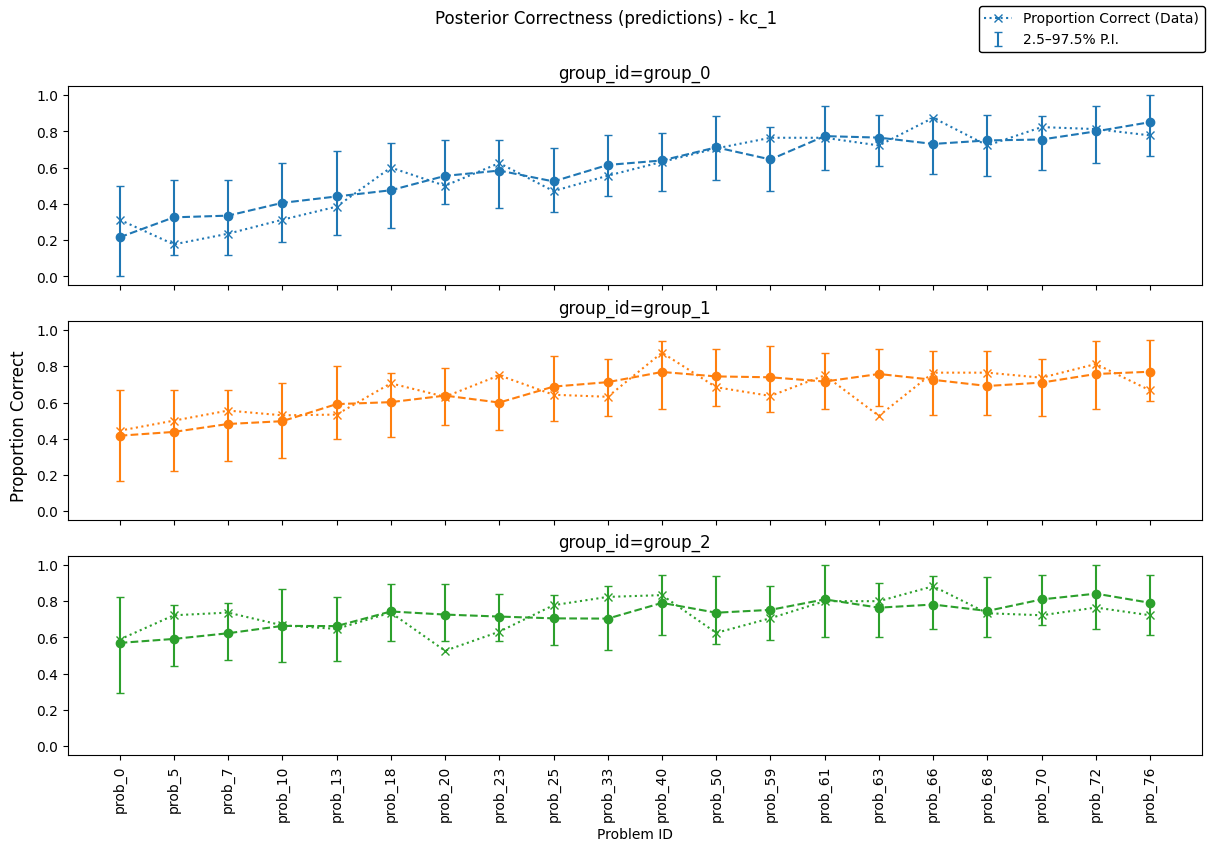

In [ ]:
axes_individual_groups = plot_posterior_correctness(
    posterior_pred_kc=pred_post_draws["kc_1"],
    data=data_df,
    column_mapping=col_mapping,
    kc="kc_1",
    type="preds",
    trajectory=True,
    grouped=True,
    frac=0.5,
)